!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!SMOTE!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## sklearn libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import confusion_matrix, classification_report

## Tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, LSTM, MaxPooling1D, GlobalAveragePooling1D, MaxPooling2D,Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Feature extraction
import tsfel

In [3]:
import DataLoader
path = r"C:\Users\willi\Desktop\PTBXL\\"

ecg_data, patient_data = DataLoader.loader(path)

ECG Data Shape: (21799, 1000, 12)
Patient Data Head:
        patient_id   age  sex  height  weight  nurse  site     device  \
ecg_id                                                                  
1          15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
2          13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
3          20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
4          17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
5          17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

             recording_date                                  report  ...  \
ecg_id                                                               ...   
1       1984-11-09 09:17:34  sinusrhythmus periphere niederspannung  ...   
2       1984-11-14 12:55:37     sinusbradykardie sonst normales ekg  ...   
3       1984-11-15 12:49:10              sinusrhythmus normales ekg  ...   
4       1984-11-15 13:44:57              sinusrhythmus 

In [4]:
import DataLoader
patient_data = DataLoader.map_classes(patient_data)
patient_data['mapped_class'].value_counts()

mapped_class
Normal ECG                9069
Myocardial Infarction     4651
Hypertrophy               2649
Conduction Disturbance    2586
ST/T Change               2433
Other                      411
Name: count, dtype: int64

In [5]:
import pandas as pd
df = pd.DataFrame()

# Extract only the first lead from the ECG signal
df['ecg_signal'] = list(ecg_data)
df['diagnosis'] = patient_data['mapped_class'].values
df['age'] = patient_data['age'].values
df = df[(df['age'] <= 100) & (df['age'] >= 18)]
df



,ecg_signal,diagnosis,age
0,"[[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004,...",Normal ECG,56.0
1,"[[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, ...",Normal ECG,19.0
2,"[[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064...",Normal ECG,37.0
3,"[[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11,...",Normal ECG,24.0
4,"[[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556,...",Normal ECG,19.0
...,...,...,...
21793,"[[-0.076, -0.029, 0.046, 0.052, -0.061, 0.008,...",Conduction Disturbance,63.0
21794,"[[-0.052, -0.034, 0.018, 0.043, -0.034, -0.008...",ST/T Change,67.0
21796,"[[0.038, 0.024, -0.014, -0.03, 0.026, 0.005, 0...",ST/T Change,59.0
21797,"[[-0.057, -0.057, 0.0, 0.057, -0.028, -0.028, ...",Normal ECG,64.0


In [6]:
df.drop(columns='age', inplace=True)
df = df[df['diagnosis'] != 'Other']
df

,ecg_signal,diagnosis
0,"[[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004,...",Normal ECG
1,"[[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, ...",Normal ECG
2,"[[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064...",Normal ECG
3,"[[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11,...",Normal ECG
4,"[[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556,...",Normal ECG
...,...,...
21793,"[[-0.076, -0.029, 0.046, 0.052, -0.061, 0.008,...",Conduction Disturbance
21794,"[[-0.052, -0.034, 0.018, 0.043, -0.034, -0.008...",ST/T Change
21796,"[[0.038, 0.024, -0.014, -0.03, 0.026, 0.005, 0...",ST/T Change
21797,"[[-0.057, -0.057, 0.0, 0.057, -0.028, -0.028, ...",Normal ECG


In [7]:
cfg = tsfel.get_features_by_domain()

features = []

for patient in df['ecg_signal']:
    signal = np.asarray(patient) 
    feat = tsfel.time_series_features_extractor(
        cfg,
        signal,
        fs=100,
        verbose=0,
        n_jobs=1
    )

    
    features.append(feat)

features_df = pd.concat(features, ignore_index=True)
features_df['diagnosis'] = df['diagnosis'].values
features_df.to_csv('tsfel_features.csv', index=False)
features_df

,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,0_ECDF_0,...,9_Wavelet variance_2.78Hz,9_Wavelet variance_25.0Hz,9_Wavelet variance_3.12Hz,9_Wavelet variance_3.57Hz,9_Wavelet variance_4.17Hz,9_Wavelet variance_5.0Hz,9_Wavelet variance_6.25Hz,9_Wavelet variance_8.33Hz,9_Zero crossing rate,diagnosis
0,11.888118,0.673645,3.0,1.190002,4.600370,200.0,800.0,-0.067,0.048,0.001,...,0.035608,0.007113,0.034062,0.030082,0.024544,0.019883,0.018223,0.018875,83.0,Normal ECG
1,17.807727,0.896710,8.0,1.782555,5.268012,200.0,800.0,-0.090,0.042,0.001,...,0.192095,0.058980,0.193954,0.187828,0.170147,0.146604,0.126969,0.113726,54.0,Normal ECG
2,14.697014,0.718870,2.0,1.471173,4.859326,200.0,800.0,-0.070,0.028,0.001,...,0.039392,0.014673,0.042151,0.042658,0.041191,0.039872,0.040410,0.040356,63.0,Normal ECG
3,19.000188,0.862950,3.0,1.901921,5.200815,200.0,800.0,-0.067,0.055,0.001,...,0.663543,0.237195,0.703766,0.733825,0.718486,0.649799,0.585517,0.582037,51.0,Normal ECG
4,6.854559,0.535630,2.0,0.686142,5.057653,200.0,800.0,-0.052,0.022,0.001,...,0.170974,0.034138,0.189583,0.198211,0.189430,0.166481,0.142331,0.120484,54.0,Normal ECG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20965,6.609367,0.557765,5.0,0.661598,5.200115,200.0,800.0,-0.063,0.034,0.001,...,0.589812,0.017168,0.532644,0.477652,0.425974,0.374275,0.308643,0.216230,41.0,Conduction Disturbance
20966,45.807704,1.227460,2.0,4.585356,4.940977,200.0,800.0,-0.128,0.055,0.001,...,0.556872,0.095415,0.528918,0.482158,0.421260,0.359687,0.312093,0.277880,118.0,ST/T Change
20967,9.297871,0.447215,2.0,0.930718,5.280866,200.0,800.0,-0.043,0.019,0.001,...,0.020290,0.018892,0.020128,0.020735,0.022307,0.025703,0.032401,0.040955,105.0,ST/T Change
20968,9.979229,0.549655,2.0,0.998922,4.978589,200.0,800.0,-0.052,0.021,0.001,...,0.112403,0.041891,0.108827,0.099152,0.085071,0.073610,0.070993,0.075092,77.0,Normal ECG


In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
from collections import Counter

# Features and labels
X = features_df.drop(columns=["diagnosis"]).to_numpy()
y_labels = features_df["diagnosis"].to_numpy()

# Clean invalid values
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Encode labels as integers first
le = LabelEncoder()
y_int = le.fit_transform(y_labels)

# Split BEFORE scaling and BEFORE SMOTE
X_train, X_val, y_train_int, y_val_int = train_test_split(
    X,
    y_int,
    test_size=0.2,
    random_state=42,
    stratify=y_int
)

# Scale using only training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("Before SMOTE:", Counter(y_train_int))

# Apply SMOTE only to training data
smote = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train_int = smote.fit_resample(X_train, y_train_int)

print("After SMOTE:", Counter(y_train_int))

# One-hot encode labels AFTER SMOTE
y_train = to_categorical(y_train_int)
y_val = to_categorical(y_val_int)

# Reshape for Conv1D
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("Classes:", le.classes_)

Before SMOTE: Counter({np.int64(3): 7153, np.int64(2): 3646, np.int64(1): 2070, np.int64(0): 2000, np.int64(4): 1907})
After SMOTE: Counter({np.int64(2): 7153, np.int64(3): 7153, np.int64(1): 7153, np.int64(4): 7153, np.int64(0): 7153})
X_train: (35765, 1872, 1) y_train: (35765, 5)
X_val: (4194, 1872, 1) y_val: (4194, 5)
Classes: ['Conduction Disturbance' 'Hypertrophy' 'Myocardial Infarction'
 'Normal ECG' 'ST/T Change']


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

timesteps = X_train.shape[1]
channels  = X_train.shape[2]
n_classes = y_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(timesteps, channels)),

    layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(64, kernel_size=2, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    
    layers.GlobalAveragePooling1D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(n_classes, activation="softmax")
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1872, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1872, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 936, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 936, 64)        │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 936, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 468, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,637 (53.27 KB)

 Trainable params: 13,445 (52.52 KB)

 Non-trainable params: 192 (768.00 B)

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 43s 37ms/step - accuracy: 0.4072 - loss: 1.3949 - val_accuracy: 0.5184 - val_loss: 1.2856 - learning_rate: 0.0010
Epoch 2/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.4753 - loss: 1.2896 - val_accuracy: 0.2856 - val_loss: 1.8898 - learning_rate: 0.0010
Epoch 3/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.5032 - loss: 1.2301 - val_accuracy: 0.5134 - val_loss: 1.2836 - learning_rate: 0.0010
Epoch 4/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.5200 - loss: 1.1975 - val_accuracy: 0.4557 - val_loss: 1.3232 - learning_rate: 0.0010
Epoch 5/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.5354 - loss: 1.1690 - val_accuracy: 0.5329 - val_loss: 1.2019 - learning_rate: 0.0010
Epoch 6/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step - accuracy: 0.5386 - loss: 1.1532 - val_accuracy: 0.2980 - val_loss: 1.8455 - learning_rate: 0.0010
Epoch 7/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accura

DENSE MODEL BECAUSE BETTER

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
from collections import Counter

# Features and labels
X = features_df.drop(columns=["diagnosis"]).to_numpy()
y_labels = features_df["diagnosis"].to_numpy()

# Clean invalid values
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Encode labels as integers first
le = LabelEncoder()
y_int = le.fit_transform(y_labels)

# Split BEFORE scaling and BEFORE SMOTE
X_train, X_val, y_train_int, y_val_int = train_test_split(
    X,
    y_int,
    test_size=0.2,
    random_state=42,
    stratify=y_int
)

# Scale using only training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("Before SMOTE:", Counter(y_train_int))

# Apply SMOTE only to training data
smote = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train_int = smote.fit_resample(X_train, y_train_int)

print("After SMOTE:", Counter(y_train_int))

# One-hot encode labels AFTER SMOTE
y_train = to_categorical(y_train_int)
y_val = to_categorical(y_val_int)


print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("Classes:", le.classes_)

Before SMOTE: Counter({np.int64(3): 7153, np.int64(2): 3646, np.int64(1): 2070, np.int64(0): 2000, np.int64(4): 1907})
After SMOTE: Counter({np.int64(2): 7153, np.int64(3): 7153, np.int64(1): 7153, np.int64(4): 7153, np.int64(0): 7153})
X_train: (35765, 1872) y_train: (35765, 5)
X_val: (4194, 1872) y_val: (4194, 5)
Classes: ['Conduction Disturbance' 'Hypertrophy' 'Myocardial Infarction'
 'Normal ECG' 'ST/T Change']


In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       479,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,501 (1.99 MB)

 Trainable params: 521,733 (1.99 MB)

 Non-trainable params: 768 (3.00 KB)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5545 - loss: 1.1407 - val_accuracy: 0.6276 - val_loss: 0.9662 - learning_rate: 0.0010
Epoch 2/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6325 - loss: 0.9547 - val_accuracy: 0.6214 - val_loss: 0.9757 - learning_rate: 0.0010
Epoch 3/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6606 - loss: 0.8828 - val_accuracy: 0.6435 - val_loss: 0.9459 - learning_rate: 0.0010
Epoch 4/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6810 - loss: 0.8355 - val_accuracy: 0.6395 - val_loss: 0.9454 - learning_rate: 0.0010
Epoch 5/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7009 - loss: 0.7906 - val_accuracy: 0.6474 - val_loss: 0.9347 - learning_rate: 0.0010
Epoch 6/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7144 - loss: 0.7501 - val_accuracy: 0.6636 - val_loss: 0.9049 - learning_rate: 0.0010
Epoch 7/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7331 - l

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_val).argmax(axis=1)
y_true = y_val.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=le.classes_))
print(confusion_matrix(y_true, y_pred))

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                        precision    recall  f1-score   support

Conduction Disturbance       0.49      0.55      0.52       500
           Hypertrophy       0.60      0.62      0.61       518
 Myocardial Infarction       0.64      0.58      0.61       911
            Normal ECG       0.85      0.75      0.80      1788
           ST/T Change       0.46      0.66      0.54       477

              accuracy                           0.66      4194
             macro avg       0.61      0.63      0.61      4194
          weighted avg       0.69      0.66      0.67      4194

[[ 275   24   77   74   50]
 [  61  320   55   23   59]
 [ 113   79  531   78  110]
 [ 108   73  112 1341  154]
 [  10   36   52   63  316]]


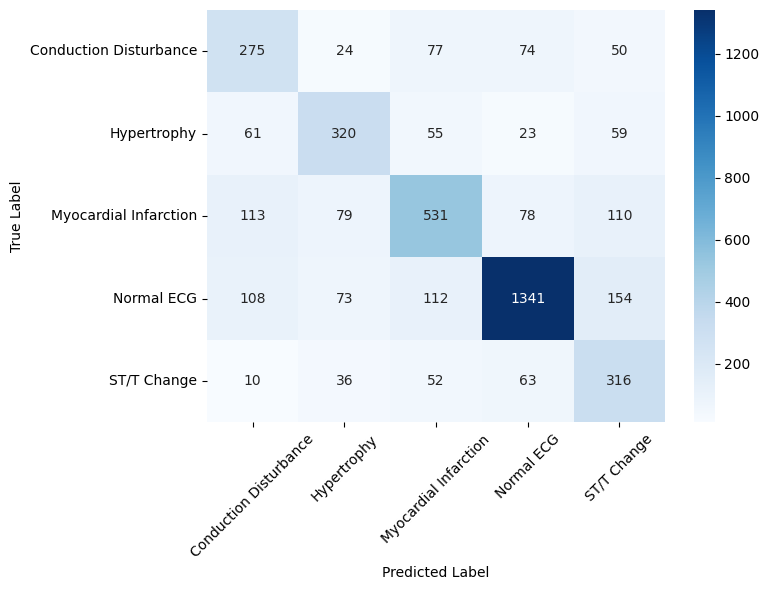

In [15]:
cm = confusion_matrix(y_true, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True, 
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()